In [5]:
from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv
from typing import TypedDict, List, Annotated, Literal
from langchain_huggingface import ChatHuggingFace, HuggingFaceEndpoint
import operator
from pydantic import BaseModel, Field
from langchain_google_genai import ChatGoogleGenerativeAI

In [2]:
load_dotenv()

True

In [3]:
llm = HuggingFaceEndpoint(
    repo_id="Qwen/Qwen3-32B",
    task="text-generation"
)

model = ChatHuggingFace(llm=llm)

/Users/harshraj/Desktop/LangGraph/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
class QuadState(TypedDict):
    a: int
    b: int
    c: int

    equation: str
    discriminant: float
    result: str

In [6]:
def real_roots(state: QuadState) -> QuadState:
    d = state['discriminant']
    a = state['a']
    b = state['b']

    root1 = (-b + d**0.5)/(2*a)
    root2 = (-b - d**0.5)/(2*a)

    return {'result': f"Two distinct real roots: {root1} and {root2}"}

def no_real_roots(state: QuadState) -> QuadState:

    return {'result': "No real roots"}

def equal_roots(state: QuadState) -> QuadState:
    d = state['discriminant']
    a = state['a']
    b = state['b']

    root = -b/(2*a)

    return {'result': f"Equal real roots: {root}"}
def checker(state: QuadState) -> Literal['real_roots', 'no_real_roots', 'equal_roots']:
    d = state['discriminant']
    if d > 0:
        return 'real_roots'
    elif d == 0:
        return 'equal_roots'
    else:
        return 'no_real_roots'

In [9]:
graph = StateGraph(QuadState)

graph.add_node('show_equation', lambda state: {'equation': f"{state['a']}x^2 + {state['b']}x + {state['c']} = 0"})
graph.add_node('calculate_discriminant', lambda state: {'discriminant': (state['b']**2) - (4*state['a']*state['c'])})
graph.add_node('real_roots',real_roots)
graph.add_node('equal_roots',equal_roots)
graph.add_node('no_real_roots',no_real_roots)

graph.add_edge(START, 'show_equation')
graph.add_edge('show_equation', 'calculate_discriminant')
graph.add_conditional_edges('calculate_discriminant', checker)
graph.add_edge('real_roots', END)
graph.add_edge('equal_roots', END)
graph.add_edge('no_real_roots', END)

workflow = graph.compile()

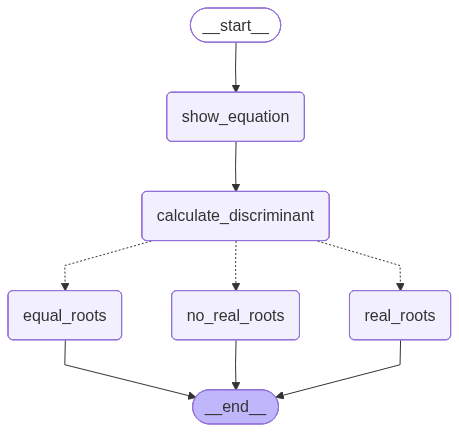

In [10]:
workflow

In [12]:
initial_state = {
    'a': 2, 
    'b': 4,
    'c': 2
}

workflow.invoke(initial_state)

{'a': 2,
 'b': 4,
 'c': 2,
 'equation': '2x^2 + 4x + 2 = 0',
 'discriminant': 0,
 'result': 'Equal real roots: -1.0'}